# Notebook 08 — Parte VI: Reducción de dimensionalidad

## Qué cubre del enunciado
**PARTE VI.** PCA sobre atributos de restaurantes y SVD truncada sobre TF-IDF de reseñas: estandarización, selección de componentes, proyecciones 2D/3D, interpretación de variables/factores, error de reconstrucción y compresión. Todo se implementa sobre NumPy en `src/dimensionality_reduction.py`, sin scikit-learn ni SciPy.

## Fundamento teórico
- El enunciado, **pág. 3**, especifica PCA por covarianza/autovalores, umbral de 90% e interpretación de PCs; también exige SVD truncada, factores latentes y reconstrucción.
- Deck **«08 - Clustering»**, pág. 11: la normalización es crítica antes de comparar ejes de features.
- Deck **«10 - Recomendación 2»**, págs. 16 y 20: `A = UΣVᵀ`, compresión de `m×n` a `(m+n)×f`, factores latentes y SVD truncada. La pág. 20 advierte que SVD clásica no debe aplicarse directamente a ratings con ~99% de entradas faltantes.

- Deck extra **«13. Reducción de Dimensionalidad»**: proyección y error de reconstrucción (págs. 11 y 25–26), mejor aproximación SVD/Frobenius (36–40), energía retenida (45), límites de interpretabilidad/dispersión (56) y tradeoff exactitud–espacio–tiempo (65–69).

## Diseño
1. **PCA:** reutiliza exactamente las 42 features estandarizadas de la Parte III, sin `metro` ni coordenadas. Así la comparación con los clusters es legítima.
2. **SVD:** usa TF-IDF de reseñas y categorías, donde los ceros significan ausencia de términos. No usamos la matriz usuario-restaurante —sus huecos son datos faltantes, no ceros— ni alteramos la evaluación temporal de la Parte IV.
3. La matriz TF-IDF permanece dispersa en CSR propio; la SVD truncada usa proyección aleatoria, multiplicaciones por bloques y autodescomposición de una matriz reducida.


In [1]:
%load_ext autoreload
%autoreload 2
import sys; sys.path.append("..")
import time
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from src import clustering as clu, dimensionality_reduction as dr, viz
from src.config import GOLD, SEED
viz.aplicar_estilo()


## Paso 1 — Validaciones controladas antes de Yelp

PCA debe ordenar primero la dirección con mayor varianza y reconstruir exactamente al conservar todos los componentes. La SVD truncada debe reconstruir una matriz de rango 2 con error prácticamente cero. Estas pruebas separan errores de implementación de los patrones que luego interpretemos en Yelp.


In [2]:
X_toy = np.array([[2., 0.], [0., 1.], [-2., 0.], [0., -1.]])
pca_toy = dr.pca_fit(X_toy)
X_toy_rec = dr.pca_inverse(pca_toy.scores, pca_toy)

A_toy = np.array([[1., 0., 1.], [0., 1., 1.], [1., 1., 2.], [2., 1., 3.]])
svd_toy = dr.randomized_svd_csr(dr.dense_to_csr(A_toy), k=2, oversampling=1, power_iterations=2)
A_toy_rec = (svd_toy.U * svd_toy.singular_values) @ svd_toy.Vt
err_pca_toy = dr.relative_frobenius_error(X_toy, X_toy_rec)
err_svd_toy = dr.relative_frobenius_error(A_toy, A_toy_rec)
assert pca_toy.explained_ratio[0] > pca_toy.explained_ratio[1]
assert err_pca_toy < 1e-12 and err_svd_toy < 1e-6
print(f"PCA toy: varianza={pca_toy.explained_ratio.round(3)} | error={err_pca_toy:.2e}")
print(f"SVD toy: singulares={svd_toy.singular_values.round(3)} | error={err_svd_toy:.2e}")


PCA toy: varianza=[0.8 0.2] | error=0.00e+00
SVD toy: singulares=[4.777 1.088] | error=4.70e-16


Las dos validaciones pasan: PCA recupera la jerarquía de varianzas esperada y ambas reconstrucciones completas/rango-real quedan en precisión numérica. Ya podemos medir compresión sin atribuir a Yelp un fallo de álgebra.

## Paso 2 — PCA formal sobre los atributos de restaurantes

Partimos de `features_negocio.parquet` y reutilizamos `preparar_matriz_features` de la Parte III. Esto conserva imputaciones, `log1p`, one-hot y estandarización, y mantiene fuera `metro`, latitud y longitud. PCA se ajusta sobre los 29,314 restaurantes completos, no sobre la muestra visual de 6,000 usada por DBSCAN.


In [3]:
t0 = time.perf_counter()
features = clu.cargar_features()
fm = clu.preparar_matriz_features(features, incluir_geo=False, incluir_mercado=False)
pca = dr.pca_fit(fm.X)
k90 = dr.n_components_for_variance(pca.explained_ratio, 0.90)
pca_curva = dr.pca_curve(pca)
loadings = dr.pca_loadings(pca, fm.feature_names)
top_pca = dr.top_loadings(loadings, n_pc=6, top_n=6)
clusters = pd.read_parquet(GOLD / "clusters_negocio.parquet", columns=["business_id", "cluster_kmeans", "segmento_kmeans"])
pca_df = pd.DataFrame(pca.scores[:, :3], columns=["PC1", "PC2", "PC3"])
pca_df.insert(0, "business_id", fm.ids)
pca_df["metro"] = fm.df["metro"].to_numpy()
pca_df = pca_df.merge(clusters, on="business_id", how="left")
full_rec = dr.pca_inverse(pca.scores, pca)
err_full = dr.relative_frobenius_error(fm.X, full_rec)
print(f"Matriz PCA: {fm.X.shape[0]:,} restaurantes × {fm.X.shape[1]} features")
print(f"PC1+PC2={pca.explained_ratio[:2].sum():.1%} | PC1+PC2+PC3={pca.explained_ratio[:3].sum():.1%}")
print(f"90% de varianza: k={k90}/{fm.X.shape[1]} | error relativo en k90={pca_curva.loc[pca_curva.k.eq(k90), 'error_relativo'].iloc[0]:.3f}")
print(f"Reconstrucción con todos los componentes: error={err_full:.2e} | tiempo={time.perf_counter()-t0:.2f}s")
print("\nVariables dominantes por PC:")
for pc in loadings.columns[:6]:
    s = loadings[pc].abs().nlargest(4).index
    print(f"  {pc}: " + ", ".join(f"{x} ({loadings.loc[x,pc]:+.2f})" for x in s))


Matriz PCA: 29,314 restaurantes × 42 features
PC1+PC2=32.4% | PC1+PC2+PC3=38.4%
90% de varianza: k=25/42 | error relativo en k90=0.309
Reconstrucción con todos los componentes: error=1.44e-15 | tiempo=0.12s

Variables dominantes por PC:
  PC1: alcohol_missing (+0.77), HasTV_missing (+0.75), RestaurantsReservations_missing (+0.72), RestaurantsGoodForGroups_missing (+0.71)
  PC2: price_range (+0.58), alcohol_none (-0.50), alcohol_full_bar (+0.47), RestaurantsTableService (+0.47)
  PC3: pct_universitarios (+0.58), mediana_ingreso (+0.56), renta_mediana (+0.54), is_open (-0.47)
  PC4: mediana_ingreso (+0.62), renta_mediana (+0.58), pct_universitarios (+0.54), alcohol_full_bar (-0.40)
  PC5: wifi_no (+0.60), wifi_free (-0.46), RestaurantsTakeOut_missing (+0.37), alcohol_none (+0.34)
  PC6: RestaurantsDelivery (+0.41), wifi_free (-0.37), RestaurantsDelivery_missing (-0.34), is_open (+0.32)


### Qué buscamos en PCA

### Lo que encontramos (PCA)

Se necesitan **25 de 42 componentes** para superar el 90% de varianza (error relativo de reconstrucción 0.309). La señal no vive en dos o tres ejes: PC1+PC2 retiene **32.4%** y agregar PC3 llega a **38.4%**. PC1 (23.8%) está dominado por indicadores de atributos faltantes; no es simple ruido, sino un eje de **documentación digital del negocio**. PC2 (8.6%) contrapone precio/bar/servicio de mesa frente a locales sin alcohol, mientras PC3-PC4 separan contexto socioeconómico ACS (educación, ingreso y renta) y apertura/modalidad. PCA confirma que los perfiles mezclan operación, tracción y barrio; ninguna variable sola organiza el mercado.


docs/figs/parte6_pca_varianza_reconstruccion.png


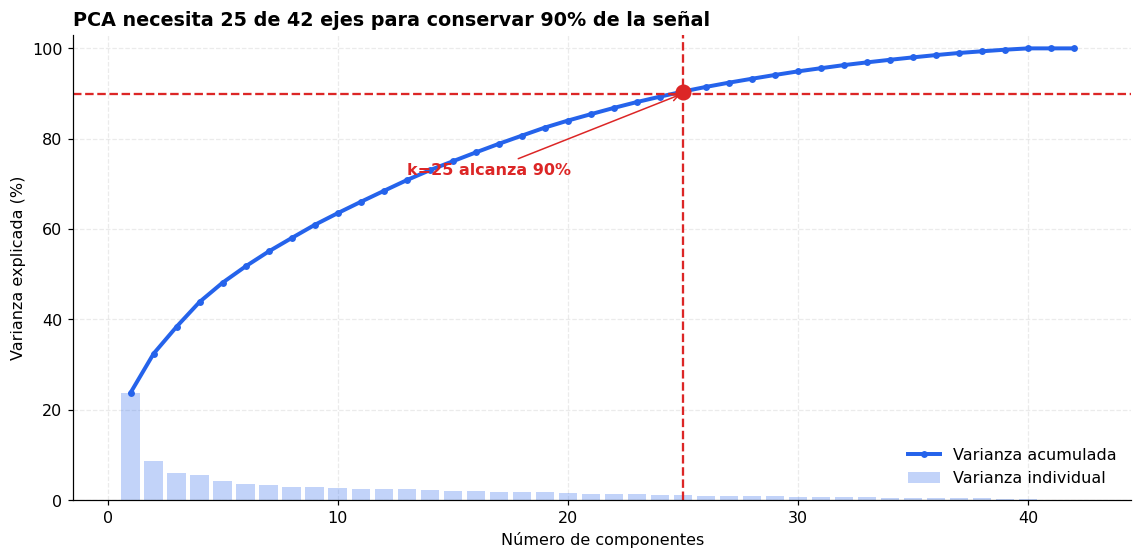

docs/figs/parte6_pca_loadings.png


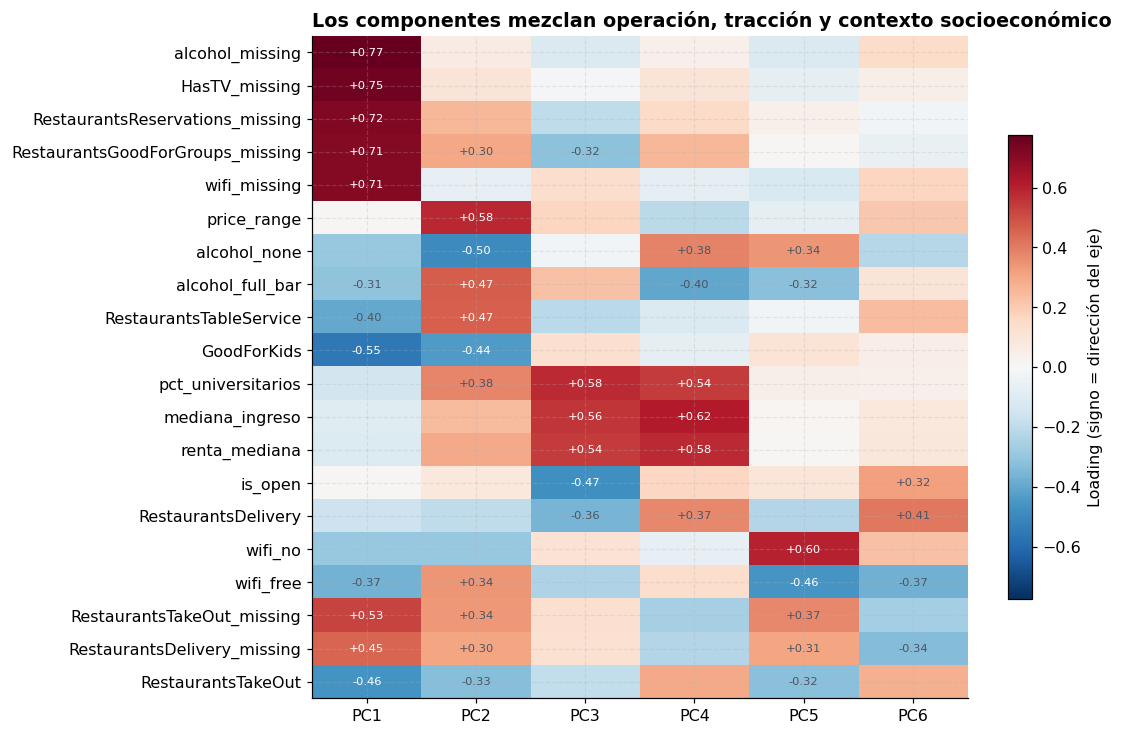

In [4]:
P = viz.PALETA
fig, ax1 = plt.subplots(figsize=(10.5, 5.2))
ax1.bar(pca_curva.k, pca.explained_ratio * 100, color=P['azul'], alpha=.28, label='Varianza individual')
ax1.plot(pca_curva.k, pca_curva.varianza_acumulada * 100, color=P['azul'], lw=2.6, marker='o', ms=3.5, label='Varianza acumulada')
ax1.axhline(90, color=P['rojo'], ls='--', lw=1.5)
ax1.axvline(k90, color=P['rojo'], ls='--', lw=1.5)
ax1.scatter([k90], [pca_curva.loc[pca_curva.k.eq(k90), 'varianza_acumulada'].iloc[0]*100], s=90, color=P['rojo'], zorder=5)
ax1.annotate(f'k={k90} alcanza 90%', (k90, 90), xytext=(k90-12, 72), arrowprops=dict(arrowstyle='->', color=P['rojo']), color=P['rojo'], fontweight='bold')
ax1.set(xlabel='Número de componentes', ylabel='Varianza explicada (%)', ylim=(0, 103))
ax1.set_title(f'PCA necesita {k90} de {fm.X.shape[1]} ejes para conservar 90% de la señal')
ax1.legend(loc='lower right')
print(viz.guardar(fig, 'parte6_pca_varianza_reconstruccion')); plt.show()

# Heatmap de loadings: unión de las cinco variables más fuertes de PC1-PC6
selected = []
for pc in loadings.columns[:6]:
    selected.extend(loadings[pc].abs().nlargest(5).index.tolist())
selected = list(dict.fromkeys(selected))
L = loadings.loc[selected, loadings.columns[:6]]
fig, ax = plt.subplots(figsize=(10.5, max(6.2, .34*len(L))))
vmax = np.abs(L.to_numpy()).max()
im = ax.imshow(L.to_numpy(), cmap='RdBu_r', vmin=-vmax, vmax=vmax, aspect='auto')
ax.set_xticks(range(6), L.columns); ax.set_yticks(range(len(L)), L.index)
for i in range(len(L)):
    for j in range(6):
        v=L.iloc[i,j]
        if abs(v)>.30: ax.text(j,i,f'{v:+.2f}',ha='center',va='center',fontsize=7.5,color='white' if abs(v)>.55*vmax else P['gris_oscuro'])
fig.colorbar(im, ax=ax, shrink=.7, label='Loading (signo = dirección del eje)')
ax.set_title('Los componentes mezclan operación, tracción y contexto socioeconómico')
print(viz.guardar(fig, 'parte6_pca_loadings')); plt.show()


La curva hace visible el costo de simplificar: un mapa atractivo de dos ejes deja fuera **67.6%** de la varianza. El heatmap explica la diversidad de la señal: PC1 captura presencia/ausencia de información; PC2, formato de servicio y precio; PC3-PC4, contexto socioeconómico; PC5-PC6, conectividad y delivery. Los signos son direcciones del eje, no juicios de “bueno” o “malo”.

## Paso 3 — Proyecciones 2D y 3D: una lente, no toda la realidad

Coloreamos PCA con las etiquetas K-Means++ ya obtenidas, pero PCA se ajustó sin verlas. Los centroides grandes ayudan a leer la tendencia; la transparencia conserva el solapamiento, que es parte del hallazgo y no ruido gráfico que debamos esconder.


docs/figs/parte6_pca_mapa_clusters.png


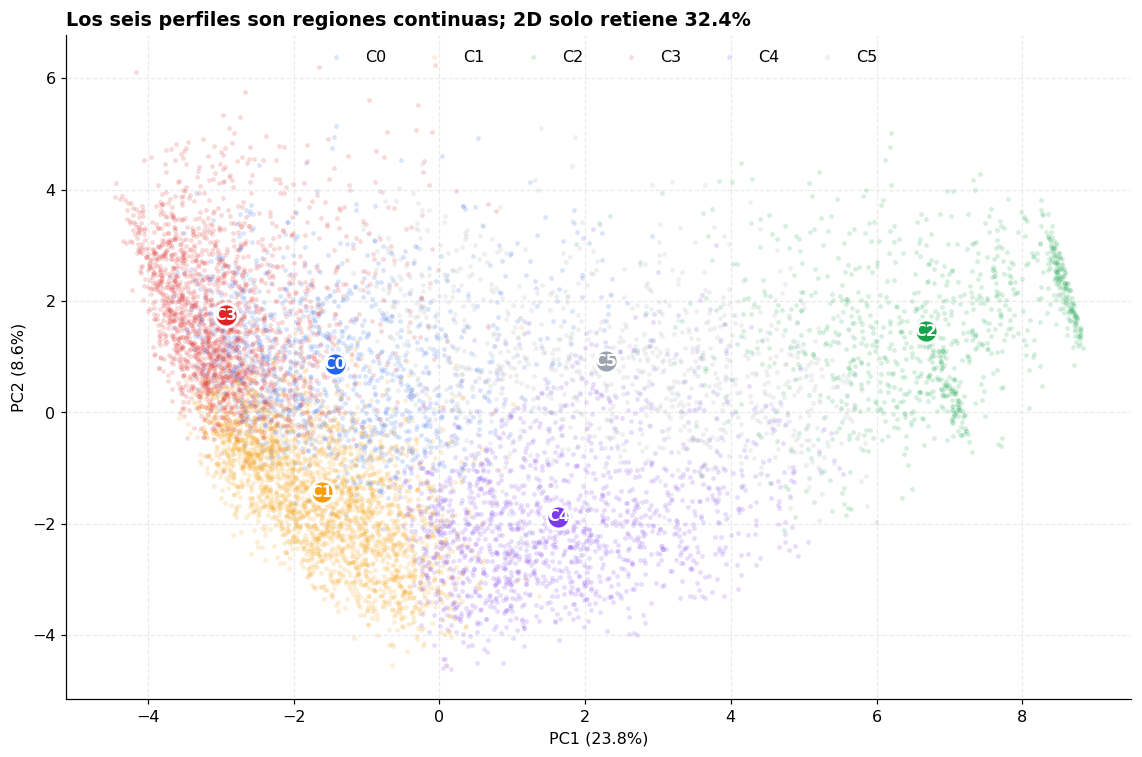

docs/figs/parte6_pca_mapa_3d.png


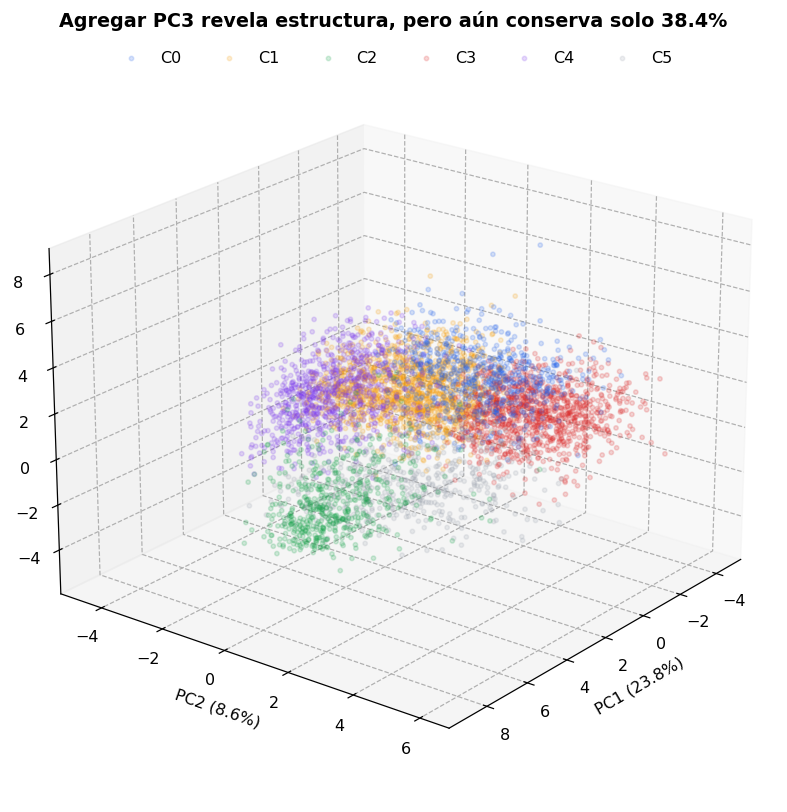

In [5]:
rng = np.random.default_rng(SEED)
sample_idx = rng.choice(len(pca_df), size=min(9000, len(pca_df)), replace=False)
plot_df = pca_df.iloc[sample_idx]
cluster_colors = {k: viz.CICLO[int(k) % len(viz.CICLO)] for k in sorted(pca_df.cluster_kmeans.dropna().unique())}
fig, ax = plt.subplots(figsize=(10.5, 7))
for k, group in plot_df.groupby('cluster_kmeans'):
    ax.scatter(group.PC1, group.PC2, s=10, alpha=.17, color=cluster_colors[k], linewidths=0, label=f'C{int(k)}')
cent = pca_df.groupby('cluster_kmeans')[["PC1","PC2"]].mean()
for k,row in cent.iterrows():
    ax.scatter(row.PC1,row.PC2,s=230,color=cluster_colors[k],edgecolor='white',lw=2,zorder=5)
    ax.text(row.PC1,row.PC2,f'C{int(k)}',ha='center',va='center',color='white',fontweight='bold',zorder=6)
ax.set(xlabel=f"PC1 ({pca.explained_ratio[0]:.1%})", ylabel=f"PC2 ({pca.explained_ratio[1]:.1%})")
ax.set_title(f'Los seis perfiles son regiones continuas; 2D solo retiene {pca.explained_ratio[:2].sum():.1%}')
ax.legend(ncol=6, loc='upper center')
print(viz.guardar(fig, 'parte6_pca_mapa_clusters')); plt.show()

from mpl_toolkits.mplot3d import Axes3D  # noqa: F401
sample3 = pca_df.iloc[rng.choice(len(pca_df), size=min(5000, len(pca_df)), replace=False)]
fig = plt.figure(figsize=(10.5, 7.5)); ax = fig.add_subplot(111, projection='3d')
for k, group in sample3.groupby('cluster_kmeans'):
    ax.scatter(group.PC1, group.PC2, group.PC3, s=8, alpha=.18, color=cluster_colors[k], label=f'C{int(k)}')
ax.set(xlabel=f'PC1 ({pca.explained_ratio[0]:.1%})', ylabel=f'PC2 ({pca.explained_ratio[1]:.1%})', zlabel=f'PC3 ({pca.explained_ratio[2]:.1%})')
ax.set_title(f'Agregar PC3 revela estructura, pero aún conserva solo {pca.explained_ratio[:3].sum():.1%}')
ax.view_init(elev=22, azim=38); ax.legend(ncol=6, loc='upper center')
print(viz.guardar(fig, 'parte6_pca_mapa_3d')); plt.show()


La vista 2D reproduce las regiones de K-Means++ sin haber usado las etiquetas: C2 (baja información) se desplaza al extremo positivo de PC1; C1 y C4 se separan sobre PC2; C0, C3 y C5 conservan mayor solapamiento. La tercera dimensión aclara parte de esa mezcla, pero 3D todavía deja fuera **61.6%**. Esto refuerza la Parte III: los clusters son perfiles operativos útiles, no especies discretas.

## Paso 4 — TF-IDF disperso para SVD

Construimos un documento por restaurante con reseñas previas a 2019 y categorías. El corte replica la Parte IV; una lista auditable de *stopwords* elimina palabras funcionales y términos genéricos para que los factores puedan interpretarse. Cada fila queda normalizada L2. La matriz completa nunca se densifica.


In [6]:
t0 = time.perf_counter()
business_ids, documents, extra_tokens, businesses = dr.cargar_corpus_restaurantes()
tfidf = dr.build_tfidf_csr(business_ids, documents, extra_tokens=extra_tokens, max_vocab=3000, min_df=10)
n_rows, n_cols = tfidf['shape']; nnz = len(tfidf['data'])
csr_mb = (tfidf['data'].nbytes + tfidf['indices'].nbytes + tfidf['indptr'].nbytes) / 2**20
dense_mb = n_rows*n_cols*4 / 2**20
print(f"TF-IDF: {n_rows:,} restaurantes × {n_cols:,} términos | nnz={nnz:,} | densidad={nnz/(n_rows*n_cols):.2%}")
print(f"Memoria float32: densa={dense_mb:,.1f} MB vs CSR={csr_mb:,.1f} MB ({dense_mb/csr_mb:.1f}× menor)")
print(f"Construcción del corpus+TF-IDF: {time.perf_counter()-t0:.1f}s")


TF-IDF: 25,952 restaurantes × 3,000 términos | nnz=4,066,982 | densidad=5.22%
Memoria float32: densa=297.0 MB vs CSR=31.2 MB (9.5× menor)
Construcción del corpus+TF-IDF: 8.9s


La matriz resultante contiene **25,952 restaurantes × 3,000 términos** y 4.07M valores no nulos (densidad 5.22%). Densa ocuparía 297 MB en float32; el CSR propio usa **31.2 MB**, 9.5× menos. Aquí un cero sí significa ausencia de un término, por lo que SVD es válida; en ratings un hueco significa “no observado”. CSR y SVD son compresiones distintas y las comparamos explícitamente.

## Paso 5 — SVD truncada, reconstrucción y factores latentes

Calculamos los primeros 80 factores mediante un subespacio aleatorio reproducible y dos iteraciones de potencia. El error se obtiene por energía de Frobenius: `sqrt(1 - Σσ²/||A||²)`. Evaluamos varios `k` sin reconstruir una matriz densa de decenas de millones de celdas.


In [7]:
t0 = time.perf_counter()
svd = dr.randomized_svd_csr(tfidf, k=80, oversampling=12, power_iterations=2, seed=SEED)
ks = [2, 5, 10, 20, 40, 60, 80]
svd_curva = dr.svd_curve(svd, ks)
svd_comp = dr.svd_compression_curve(tfidf, ks)
svd_eval = svd_curva.merge(svd_comp, on='k')
factor_terms = dr.svd_factor_terms(svd, tfidf['inverse_vocab'], n_factors=8, top_n=8)
factor_businesses = dr.svd_representative_businesses(svd, business_ids, businesses, n_factors=8, top_n=5)
orth_u = np.max(np.abs(svd.U.T @ svd.U - np.eye(len(svd.singular_values))))
orth_v = np.max(np.abs(svd.Vt @ svd.Vt.T - np.eye(len(svd.singular_values))))
print(f"SVD truncada k=80: {time.perf_counter()-t0:.1f}s | σ1/σ2={svd.singular_values[0]/svd.singular_values[1]:.2f}")
print(f"Ortogonalidad: max|UᵀU-I|={orth_u:.2e} | max|VVᵀ-I|={orth_v:.2e}")
print(svd_eval[['k','energia_capturada','error_relativo','compresion_vs_densa','ratio_bytes_vs_csr']].to_string(index=False, formatters={
    'energia_capturada':'{:.1%}'.format, 'error_relativo':'{:.3f}'.format,
    'compresion_vs_densa':'{:.1f}×'.format, 'ratio_bytes_vs_csr':'{:.2f}×'.format}))
print('\nTérminos positivos dominantes (F2-F8):')
for f in range(2,9):
    q=factor_terms.query('factor==@f and lado=="positivo"').sort_values('rango').head(6)
    print(f"  F{f}: " + ', '.join(q.termino))
print('\nRestaurantes en los extremos (F2-F7):')
for f in range(2,8):
    pos=factor_businesses.query('factor==@f and lado=="positivo"').sort_values('rango').head(2).name.tolist()
    neg=factor_businesses.query('factor==@f and lado=="negativo"').sort_values('rango').head(2).name.tolist()
    print(f"  F{f}: + {', '.join(pos)} | − {', '.join(neg)}")


SVD truncada k=80: 1.8s | σ1/σ2=2.94
Ortogonalidad: max|UᵀU-I|=3.55e-15 | max|VVᵀ-I|=1.00e-14
 k energia_capturada error_relativo compresion_vs_densa ratio_bytes_vs_csr
 2             10.1%          0.948             1344.5×              0.01×
 5             12.3%          0.936              537.8×              0.02×
10             14.5%          0.925              268.9×              0.04×
20             17.0%          0.911              134.5×              0.07×
40             20.1%          0.894               67.2×              0.14×
60             22.0%          0.883               44.8×              0.21×
80             23.4%          0.875               33.6×              0.28×

Términos positivos dominantes (F2-F8):
  F2: pizza, delivery, crust, cat_pizza, cheese, pizzas
  F3: chinese, rice, sushi, rolls, chicken, fried
  F4: pizza, bar, night, beer, wings, cat_pizza
  F5: drive, thru, chinese, minutes, cat_fast_food, worst
  F6: mexican, tacos, taco, salsa, cat_mexican, burrit

### Lo que encontramos (SVD)

El texto tiene una **cola larga de señal**: 80 factores capturan 23.4% de la energía y dejan error relativo 0.875. Esto no invalida SVD; cuantifica que reseñas y cocinas son diversas y que una reconstrucción fiel necesita muchos ejes. Aun así, `k=80` reduce la matriz densa 33.6× y ocupa solo 28% del CSR; `k=20` comprime 134.5× frente a densa y usa 7% del CSR, a cambio de capturar 17.0%.

Los factores sí son interpretables. F2 contrapone **pizza/delivery** frente a bar/cena; F3, **comida asiática/sushi** frente a breakfast/coffee; F5 separa **drive-thru/fast food** —con términos `minutes` y `worst` y extremos de baja valoración— de cafés y sándwiches; F6 contrapone **mexicano/tacos** con sushi/chino; F7 distingue beer/bar/wings de cena italiana. SVD descubre simultáneamente cocina, formato y experiencia, no una sola taxonomía.


docs/figs/parte6_svd_error_compresion.png


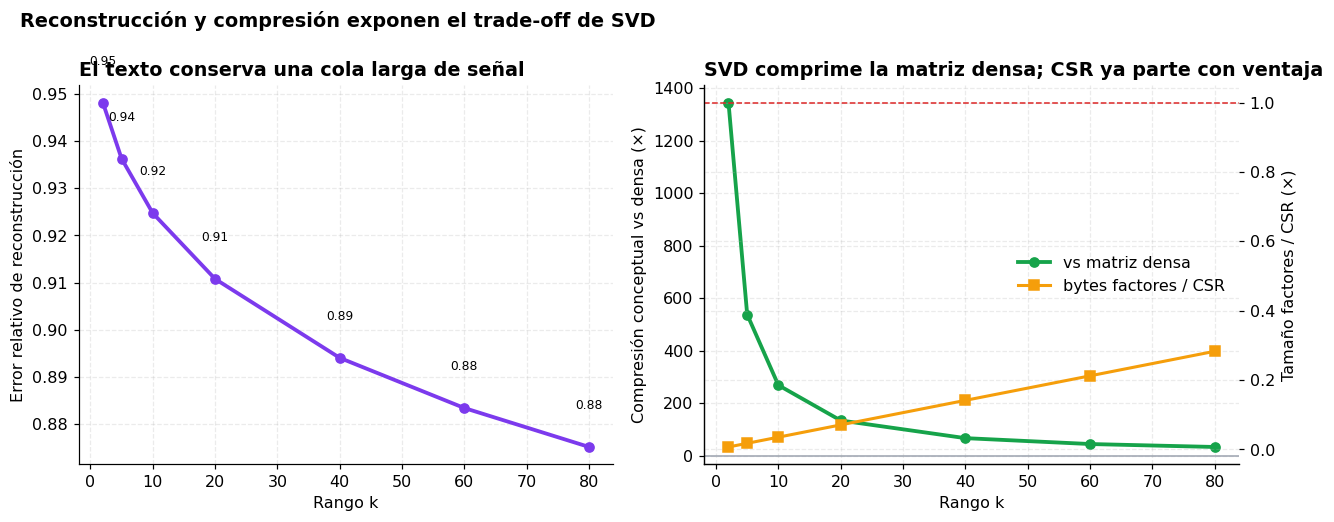

docs/figs/parte6_svd_factores_terminos.png


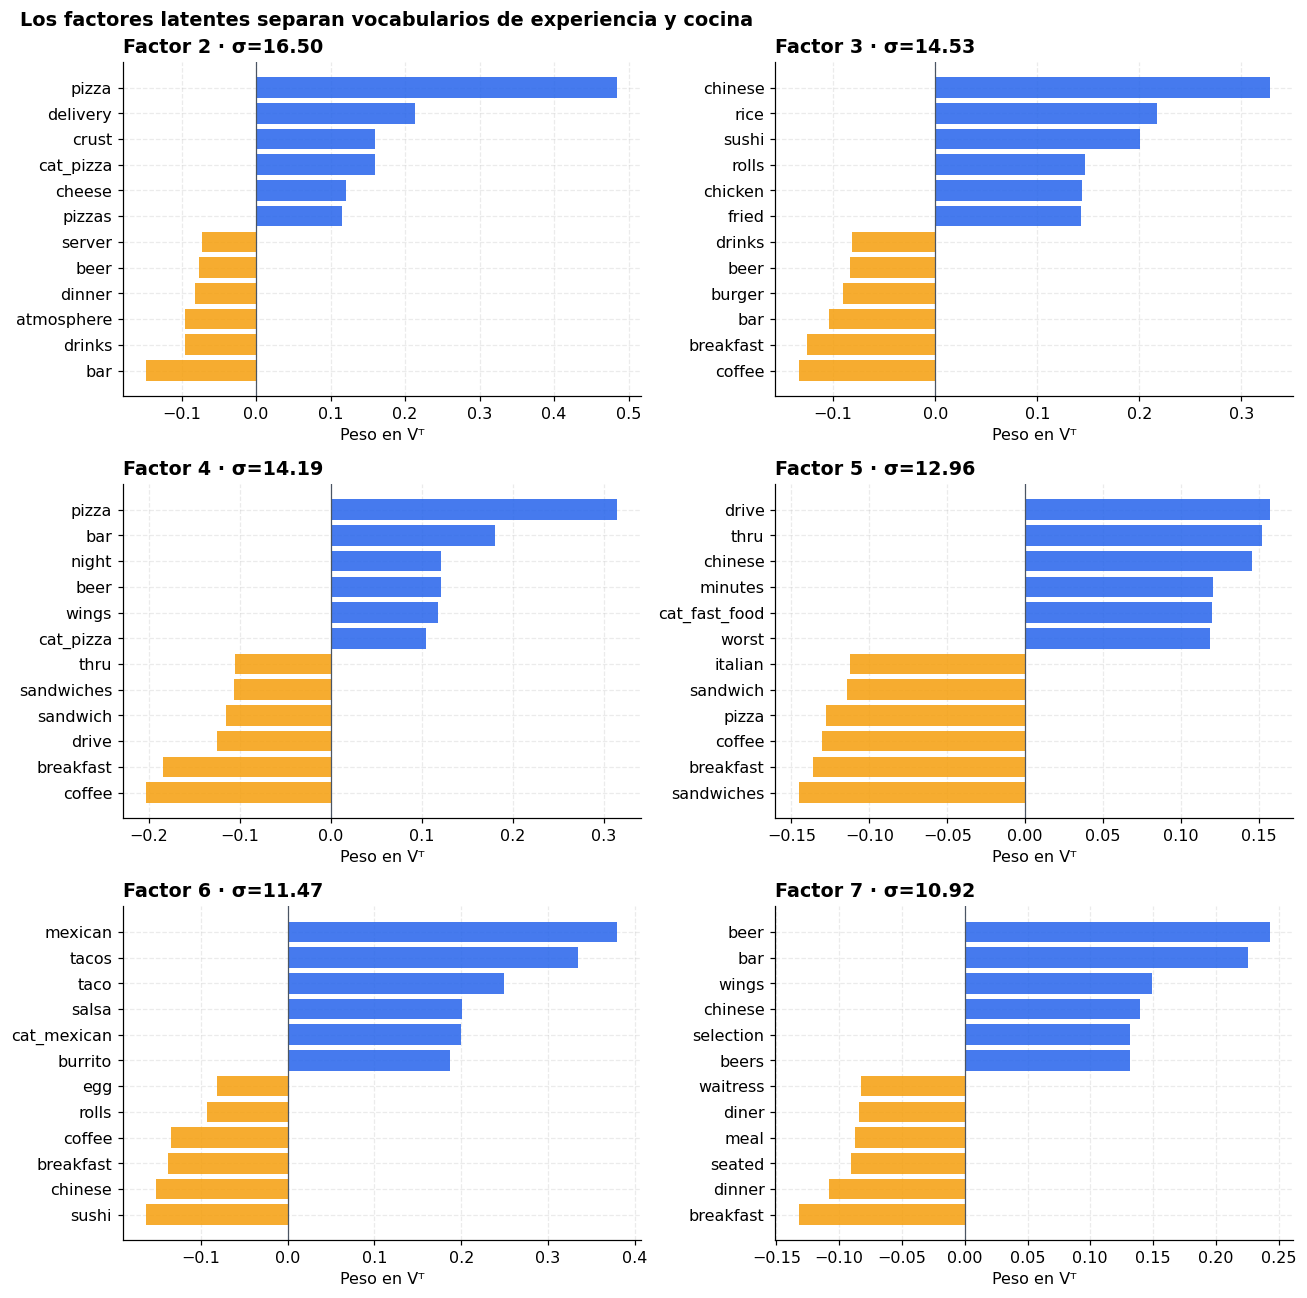

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.8))
ax=axes[0]
ax.plot(svd_eval.k, svd_eval.error_relativo, marker='o', lw=2.5, color=P['morado'])
for _,r in svd_eval.iterrows(): ax.text(r.k, r.error_relativo+.008, f"{r.error_relativo:.2f}", ha='center', fontsize=8)
ax.set(xlabel='Rango k', ylabel='Error relativo de reconstrucción', title='El texto conserva una cola larga de señal')
ax=axes[1]
line_dense, = ax.plot(svd_eval.k, svd_eval.compresion_vs_densa, marker='o', color=P['verde'], lw=2.5, label='vs matriz densa')
ax2=ax.twinx(); line_csr, = ax2.plot(svd_eval.k, svd_eval.ratio_bytes_vs_csr, marker='s', color=P['naranja'], lw=2, label='bytes factores / CSR')
ax.axhline(1,color=P['gris'],lw=1); ax2.axhline(1,color=P['rojo'],ls='--',lw=1)
ax.set(xlabel='Rango k', ylabel='Compresión conceptual vs densa (×)', title='SVD comprime la matriz densa; CSR ya parte con ventaja')
ax2.set_ylabel('Tamaño factores / CSR (×)')
ax.legend([line_dense,line_csr],[line_dense.get_label(),line_csr.get_label()],loc='center right')
fig.suptitle('Reconstrucción y compresión exponen el trade-off de SVD', fontweight='bold', x=.02, ha='left')
print(viz.guardar(fig, 'parte6_svd_error_compresion')); plt.show()

# Barras semánticas: factores 2-7 (F1 es el fondo común positivo)
fig, axes = plt.subplots(3, 2, figsize=(12, 12))
for ax,f in zip(axes.ravel(), range(2,8)):
    q=factor_terms.query('factor==@f').copy()
    q=q.groupby('lado',group_keys=False).head(6).sort_values('peso')
    colors=np.where(q.peso>=0,P['azul'],P['naranja'])
    ax.barh(q.termino,q.peso,color=colors,alpha=.85)
    ax.axvline(0,color=P['gris_oscuro'],lw=.8); ax.set_title(f'Factor {f} · σ={svd.singular_values[f-1]:.2f}')
    ax.set_xlabel('Peso en Vᵀ')
fig.suptitle('Los factores latentes separan vocabularios de experiencia y cocina', fontweight='bold', x=.02, ha='left')
print(viz.guardar(fig, 'parte6_svd_factores_terminos')); plt.show()


## Paso 6 — Persistencia para el informe y la Parte VII

Persistimos resultados pequeños e interpretables, no la matriz intermedia: proyección PCA, componentes/loadings, curva de SVD, términos y restaurantes representativos. Los tiempos, tamaños y pérdidas alimentarán el análisis de escalabilidad de la Parte VII.


In [9]:
pca_df.to_parquet(GOLD / 'proyeccion_pca_restaurantes.parquet', index=False)
pca_components = loadings.reset_index(names='feature').melt(id_vars='feature', var_name='componente', value_name='loading')
pca_components = pca_components.merge(pd.DataFrame({'componente':loadings.columns, 'varianza_explicada':pca.explained_ratio, 'varianza_acumulada':np.cumsum(pca.explained_ratio)}), on='componente')
pca_components.to_parquet(GOLD / 'componentes_pca.parquet', index=False)
svd_eval.to_parquet(GOLD / 'curva_svd_compresion.parquet', index=False)
factor_terms.to_parquet(GOLD / 'factores_svd_terminos.parquet', index=False)
factor_businesses.to_parquet(GOLD / 'factores_svd_restaurantes.parquet', index=False)
print('Guardadas 5 tablas gold: proyección/componentes PCA + curva/términos/restaurantes SVD')


Guardadas 5 tablas gold: proyección/componentes PCA + curva/términos/restaurantes SVD


## Resumen del notebook

1. PCA se ajustó sobre el universo completo y formalizó la proyección diagnóstica de la Parte III: umbral de 90%, reconstrucción, loadings y mapas 2D/3D.
2. Los mapas muestran tendencias continuas; nunca se interpretan sin declarar la varianza que dejan fuera.
3. SVD se aplicó a TF-IDF, no a la matriz de ratings incompleta, siguiendo la advertencia explícita del deck 10.
4. La curva rango-error-compresión cuantifica qué compra cada factor adicional; los términos y restaurantes extremos vuelven interpretables los patrones latentes.
5. Persistimos cinco tablas gold y seis figuras para informe/presentación.

**Parte VI completa:** PCA 90%+ ✓ · covarianza/eigen ✓ · 2D/3D ✓ · loadings ✓ · SVD truncada ✓ · factores latentes ✓ · reconstrucción ✓ · compresión vs pérdida ✓.
